In [181]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
from scipy import linalg as la
import model as m

NOTE: $D$ apparently is not a 'controllable' variable. So including it in our state equation + cost functional is bad. We changed the model so if you specify `no_dead=True` in the constructor then it will not output $D$ which is fine because we can compute it by subtracting the sum of the other variables from the total initial population. - Jeremy + Henry.

In [182]:
# Define Q and R in our LQR model
Q = np.array([[0, 0, 0],
             [0, 3, 0],
             [0, 0, 0]]) 

R = np.eye(2)

tf = 10 # total length of time full solution will be on (so tf = M * tn where M is however many times we linearize)

def solve_linearized_infinite(A, B, y0, t0, tf):
    '''
    Solve for control and state given a linearized system on an interval of length tn
    x_dot = Ax + Bu
    y0 - initial conditions (or last value or previous solution to linearized system)
    tn - length of one time that system is linearized on

    returns a solution to linerized system for tn years (run solve_linearized multiple times and then
    concatenate the solutions together)

    Basically one iteration of iterated LQR (?)
    '''

    # solve continuous algebraic Riccati equation to get P
    P = la.solve_continuous_are(A, B, Q, R)


    # state equation Ax + 1/2 B R^-1 B^T lambda but lambda = -2Px by 
    def chytrid_evolve(t, y):
        return (A @ y - B @ B.T @ P @ y) # no R^-1 since thats just I

    #s olve the optimal state evolution, and plot the position & velocity
    sol = solve_ivp(chytrid_evolve, [0, tf], y0, dense_output=True)
    t = np.linspace(t0, tf, 10)
    # S, I, T1, D = sol.sol(t)
    S = sol.sol(t)[0]
    I = sol.sol(t)[1]
    T1 = sol.sol(t)[2]


    # can prob just return the solution but just wanted to plot to test
    # plt.title("Optimal State for Linearized Chytrid")
    # plt.plot(t, S, label="Susceptible")
    # plt.plot(t, I, label="Infected")
    # plt.plot(t, T1, label="In Treatment 1")
    # plt.plot(t, D, label="Death")
    # plt.legend()

    u = - B.T @ P @ sol.sol(t)  # control

    return np.array([S[0], I[0], T1[0]]), u[:, 0]


In [183]:
def solve_linearized_finite(A, B, y0, t0, tf):
    '''
    Solve for control and state given a linearized system on an interval of length tn
    x_dot = Ax + Bu
    y0 - initial conditions (or last value or previous solution to linearized system)
    tn - length of one time that system is linearized on

    returns a solution to linerized system for tn years (run solve_linearized multiple times and then
    concatenate the solutions together)

    Basically one iteration of iterated LQR (?)
    '''
    t_steps = 10
    t_space = np.linspace(t0, tf, t_steps)

    def P_evolve(t, p): # riccatti ode
        P = p.reshape(A.shape[0], A.shape[0])
        return (-P @ A - A.T @ P - Q + P @ B @  B.T @ P).flatten()
    
    pf = np.zeros(A.shape[0]**2)    # P(t_f) = M = 0
    sol_P = solve_ivp(P_evolve, [tf, t0], pf, dense_output=True, t_eval=t_space[::-1]) # solve backwards
    p = sol_P.y
    P = p.reshape(sol_P.t.shape[0], A.shape[0], A.shape[0])[::-1]

    # state equation Ax + 1/2 B R^-1 B^T lambda but lambda = -2Px by 
    def chytrid_evolve(t, y):
        P = sol_P.sol(t).reshape(A.shape[0], A.shape[0])
        return (A @ y - B @ B.T @ P @ y) # no R^-1 since thats just I

    # solve the optimal state evolution, and plot the position & velocity
    sol_x = solve_ivp(chytrid_evolve, [t0, tf], y0, dense_output=True, t_eval=t_space)

    # S, I, T1, D = sol.sol(t)
    S = sol_x.sol(t_space)[0]
    I = sol_x.sol(t_space)[1]
    T1 = sol_x.sol(t_space)[2]

    u = - B.T @ P[0] @ sol_x.sol(t_space)  # control

    return np.array([S[0], I[0], T1[0]]), u[:, 0]

In [184]:
# test
y0 = np.array([475, 25, 0])
u0 = np.array([0, 1])

tf = 10
t_steps = 5000
t_space = np.linspace(0, tf, t_steps)
model = m.Model(seasonal=False, no_dead=True)


<class 'sympy.matrices.dense.MutableDenseMatrix'> Matrix([[-I*S*α + I*u2*η/(100*I + 5000) - S*ζ*(-2*T1/(365*u1) + 1) + T1*γ], [I*S*α - I*u2*η/(100*I + 5000) - I*β - I*ζ*(-2*T1/(365*u1) + 1)], [-T1*γ + ζ*(I + S)*(-2*T1/(365*u1) + 1)]])


(5000, 3) (5000, 2)


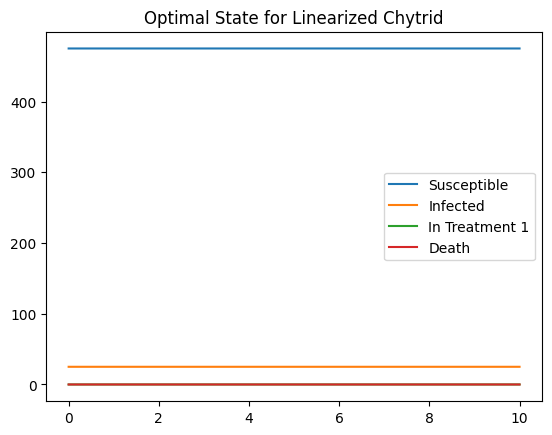

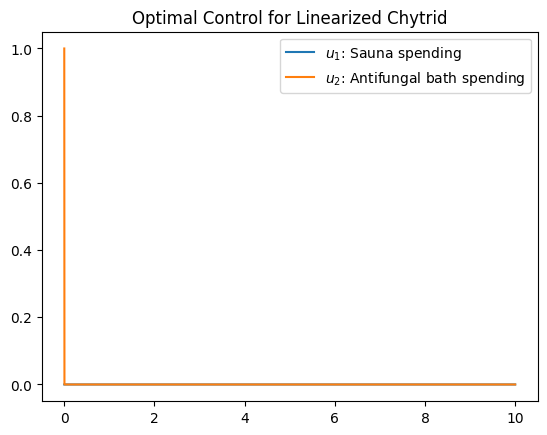

In [185]:
def iterated_lqr(Df_x, Df_u, t_space, x0, u0):
    '''
    Solve for control and state solutions at discrete steps using LQR at each step
    Args:
        Df_x: a function to linearize with respect to x, returns matrix A for LQR
        Df_u: a function to linearize with respect to x, returns matrix B for LQR
        t_space: time steps on which to evaluate our solution
        x0: initial state
        u0: initial control

    Returns:
        state_solutions: array of optimal state over time
        control_solutions: array of optimal control over time

    '''
    # store initial states in our solution
    state_solutions = [x0]
    control_solutions = [u0]


    for i in range(len(t_space) - 1):   # iterate through each time step
        A = Df_x(0, state_solutions[i], control_solutions[i])    # TODO write these functions
        B = Df_u(0, state_solutions[i], control_solutions[i])

        # # test
        # A[-1] = 1e-5
        # A[:,-1] = 1e-5
        # B[-1] = 1e-5

        # print(A)
        # print(type(A))

        x_new, u_new = solve_linearized_finite(A, B, state_solutions[i], t_space[i], t_space[i+1])   # get next state using LQR
        state_solutions.append(x_new)
        control_solutions.append(u_new)


    return np.array(state_solutions), np.array(control_solutions)

# sample test case
x, u = iterated_lqr(lambda t, x, u: model.f_x(t, x, u), lambda t, x, u: model.f_u(t, x, u), t_space, y0, u0)
print(x.shape, u.shape)

S = x[:, 0]
I = x[:, 1]
T1 = x[:, 2]

plt.title("Optimal State for Linearized Chytrid")
plt.plot(t_space, S, label="Susceptible")
plt.plot(t_space, I, label="Infected")
plt.plot(t_space, T1, label="In Treatment 1")
plt.plot(t_space, 500 - S - I - T1, label="Death")  # plotting death total 500 - all other groups
plt.legend()
plt.show()

plt.title("Optimal Control for Linearized Chytrid")
u1, u2 = u.T
plt.plot(t_space, u1, label=rf'$u_{1}$: Sauna spending')
plt.plot(t_space, u2, label=rf'$u_{2}$: Antifungal bath spending') 
plt.legend()

In [186]:
type(model.f_x(0, np.ones(3), np.ones(2)))

numpy.ndarray